In [1]:
import os

In [3]:
os.path.basename("/cluster/scratch/vogtva/models/hp/model301")

'model301'

In [2]:
import xarray as xr
import numpy as np
import re
import glob
from collections import defaultdict

In [14]:
prefix = "/cluster/scratch/vogtva/out/stat/"
# Get all .npy files
files = glob.glob(prefix + "pred_pattern_*_batch_*_jump_*.npy")
res = []
# # Parse filenames into (pattern, batch, jump) → filepath
pattern_re = re.compile(r"pattern_(\d+)_batch_(\d+)_jump_(\d+)\.npy")
filemap = defaultdict(lambda: defaultdict(dict))

for f in files:
    match = pattern_re.search(f)
    if match:
        p, b, j = map(int, match.groups())
        res.append([p, b, j])

res = np.array(res)

data = {}
patterns = np.unique(res[:, 0])
batch_indices = np.unique(
    res[:, 1]
)  # Fill this with your batch indices (e.g. range(N))

for p in patterns:
    data[p] = {}
    for b in batch_indices:
        data[p][b] = {}
        for j in range(p):
            filename = prefix + f"pred_pattern_{p}_batch_{b}_jump_{j}.npy"
            data[p][b][j] = np.load(filename)

np.savez(
    "/cluster/scratch/vogtva/out/merged_data.npz",
    **{
        f"{p}_{b}_{j}": data[p][b][j] for p in data for b in data[p] for j in data[p][b]
    },
)


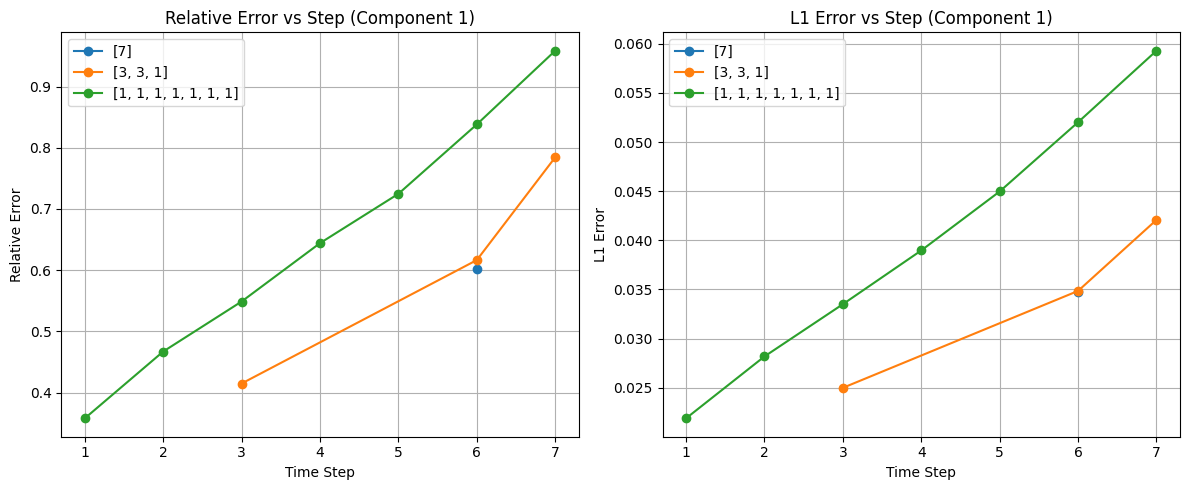

In [1]:
import matplotlib.pyplot as plt

# Data for component 1 with corrected step 7
patterns = {
    "[7]": {
        "steps": [6],
        "rel_errors": [0.602132],
        "l1_errors": [0.034755]
    },
    "[3, 3, 1]": {
        "steps": [3, 6, 7],  # relabeling 6.1 → 7
        "rel_errors": [0.414702, 0.616459, 0.784423],
        "l1_errors": [0.024992, 0.034854, 0.042082]
    },
    "[1, 1, 1, 1, 1, 1, 1]": {
        "steps": [1, 2, 3, 4, 5, 6, 7],  # relabeling last 6.1 → 7
        "rel_errors": [0.357779, 0.466968, 0.548706, 0.644114, 0.724757, 0.838172, 0.958609],
        "l1_errors": [0.021888, 0.028183, 0.033502, 0.038971, 0.044972, 0.052020, 0.059295]
    }
}

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot relative errors
for label, d in patterns.items():
    axs[0].plot(d["steps"], d["rel_errors"], marker='o', label=label)
axs[0].set_title("Relative Error vs Step (Component 1)")
axs[0].set_xlabel("Time Step")
axs[0].set_ylabel("Relative Error")
axs[0].legend()
axs[0].grid(True)

# Plot L1 errors
for label, d in patterns.items():
    axs[1].plot(d["steps"], d["l1_errors"], marker='o', label=label)
axs[1].set_title("L1 Error vs Step (Component 1)")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("L1 Error")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()
